#Librerías

In [ ]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
#Google Drive
drive.mount('/content/drive')

# Ruta
file_path = "/content/drive/MyDrive/Colab Notebooks/IDA_LIMPIO.csv"

# Leer el archivo CSV
df = pd.read_csv(file_path)

Mounted at /content/drive


In [ ]:
date_columns = [
    'End of Period', 'First Repayment Date', 'Last Repayment Date',
    'Agreement Signing Date', 'Board Approval Date', 'Effective Date (Most Recent)',
    'Closed Date (Most Recent)']
df[date_columns] = df[date_columns].apply(pd.to_datetime, errors='coerce')

df['Region'] = df['Region'].str.upper()
df['Credit Number'] = df['Credit Number'].astype('string')
df['credit_status_group'] = df['credit_status_group'].astype('string')

In [ ]:
date_cols = ['First Repayment Date', 'Last Repayment Date']
df = df.assign(**{
    **{f'{col}_year': df[col].dt.year for col in date_cols},
    **{f'{col}_month': df[col].dt.month for col in date_cols},
    **{f'{col}_day': df[col].dt.day for col in date_cols},
})

# Modelo 1

In [ ]:
# Definir features
numeric_features = ['Original Principal Amount (US$)', 'Service Charge Rate','Cancelled Amount (US$)', 'Undisbursed Amount (US$)','Disbursed Amount (US$)', 'Repaid to IDA (US$)',
                    'Due to IDA (US$)','First Repayment Date_year' ,'Last Repayment Date_year' ,'First Repayment Date_month' ,'Last Repayment Date_month',
                    'First Repayment Date_day','Last Repayment Date_day']
categorical_features = ['Region', 'borrower_type','Country / Economy Code']

# Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced'))
])

# Train-test split
X = df[numeric_features + categorical_features]
y = df['credit_status_group']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=46)

# Entrenamiento
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Original Principal Amount '
                                                   '(US$)',
                                                   'Service Charge Rate',
                                                   'Cancelled Amount (US$)',
                                                   'Undisbursed Amount (US$)',
                                                   'Disbursed Amount (US$)',
                                                   'Repaid to IDA (US$)',
                                                   'Due to IDA (US$)',
                                                   'First Repayment Date_year',
                                                   'Last Repayment Date_year',
                                                   'First Repayment Date_month',
                                                   'Last Repayment Date_month',
                                                   'First Repayment Date_day',
                                                   'Last Repayment Date_day']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Region', 'borrower_type',
                                                   'Country / Economy '
                                                   'Code'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced'))])

Classification Report:
                 precision    recall  f1-score   support

         Activo       1.00      0.99      0.99    153623
      Cancelado       0.99      1.00      0.99      2581
No Desembolsado       0.64      0.70      0.67      1449
    Reembolsado       0.99      1.00      1.00     71755

       accuracy                           0.99    229408
      macro avg       0.90      0.92      0.91    229408
   weighted avg       0.99      0.99      0.99    229408


Matriz de Confusión (Counts):
[[152473     26    565    559]
 [     0   2576      5      0]
 [   433      1   1015      0]
 [    56      0      0  71699]]


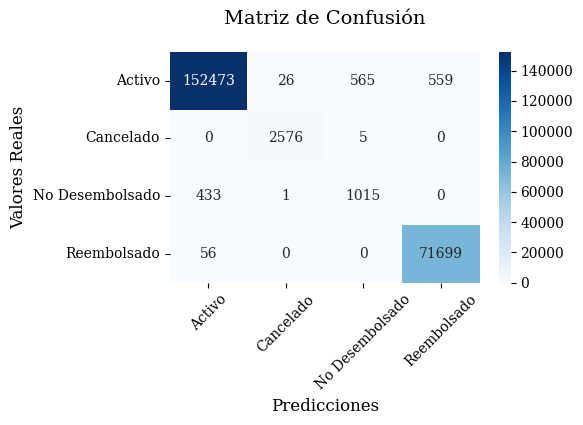

In [ ]:
y_pred1 = pipeline.predict(X_test)

#Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred1))

#Matriz de Confusión
print("\nMatriz de Confusión (Counts):")
print(confusion_matrix(y_test, y_pred1))

#Visualización
plt.rcParams['font.family'] = 'serif'
plt.figure(figsize=(5, 3))
cm = confusion_matrix(y_test, y_pred1)
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=pipeline.classes_,
            yticklabels=pipeline.classes_)

plt.title('Matriz de Confusión', pad=20, fontsize=14)
plt.xlabel('Predicciones', fontsize=12)
plt.ylabel('Valores Reales', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

In [ ]:
report1=classification_report(y_test, y_pred1, output_dict=True)

In [ ]:
report_df = pd.DataFrame(report1).transpose()

report_df_filtered = report_df.drop(index='accuracy')

styled_report = (report_df_filtered.style
                .format("{:.2f}", subset=['precision', 'recall', 'f1-score'])
                .format("{:.0f}", subset=['support'])
                .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
                .set_caption("Classification Report"))
styled_report

,precision,recall,f1-score,support
Activo,1.00,0.99,0.99,153623
Cancelado,0.99,1.00,0.99,2581
No Desembolsado,0.64,0.70,0.67,1449
Reembolsado,0.99,1.00,1.00,71755
macro avg,0.90,0.92,0.91,229408
weighted avg,0.99,0.99,0.99,229408


<ipython-input-12-d3332ada0f4d>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


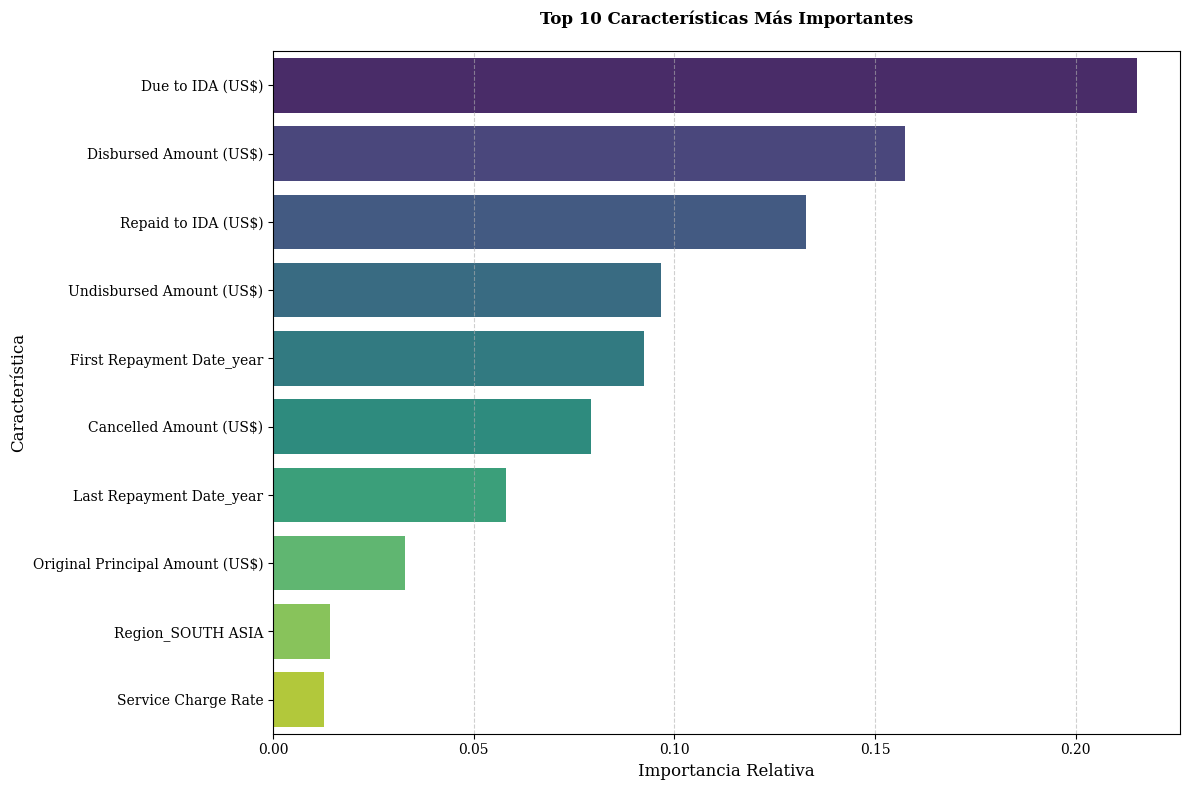

                            Feature  Importance
                   Due to IDA (US$)    0.215221
             Disbursed Amount (US$)    0.157446
                Repaid to IDA (US$)    0.132843
           Undisbursed Amount (US$)    0.096769
          First Repayment Date_year    0.092491
             Cancelled Amount (US$)    0.079233
           Last Repayment Date_year    0.058011
    Original Principal Amount (US$)    0.032893
                  Region_SOUTH ASIA    0.014341
                Service Charge Rate    0.012852
     Region_EUROPE AND CENTRAL ASIA    0.008206
          Last Repayment Date_month    0.007824
                      Region_AFRICA    0.007709
         First Repayment Date_month    0.006307
       Region_EAST ASIA AND PACIFIC    0.005665
Region_MIDDLE EAST AND NORTH AFRICA    0.005383
            Last Repayment Date_day    0.004568
          Country / Economy Code_PK    0.004533
          Country / Economy Code_GH    0.003889
           First Repayment Date_day    0

In [ ]:
# Obtener los nombres de las características después del preprocesamiento
numeric_feature_names = numeric_features

# Para variables categóricas
categorical_encoder = pipeline.named_steps['preprocessor'].named_transformers_['cat']
categorical_feature_names = categorical_encoder.get_feature_names_out(categorical_features)

# Combinar todos los nombres
all_feature_names = numeric_feature_names + list(categorical_feature_names)

importances = pipeline.named_steps['classifier'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Visualizar las top 10 más importantes
plt.figure(figsize=(12, 8))
sns.barplot(
    data=feature_importance_df.head(10),
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title('Top 10 Características Más Importantes', fontweight='bold', pad=20)
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Característica', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 5. Mostrar tabla
print(feature_importance_df.head(20).to_string(index=False))

#Modelo 2

Importancia > 0.05

In [ ]:
# Definir features
numeric_features = ['Cancelled Amount (US$)', 'Undisbursed Amount (US$)','Disbursed Amount (US$)', 'Repaid to IDA (US$)',
                    'Due to IDA (US$)','First Repayment Date_year' ,'Last Repayment Date_year']
#categorical_features = ['Region']

# Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ])

# Pipeline
pipeline3 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced'))
])

# Train-test split
#X = df[numeric_features + categorical_features]
X = df[numeric_features]
y = df['credit_status_group']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=46)

# Entrenamiento
pipeline3.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Cancelled Amount (US$)',
                                                   'Undisbursed Amount (US$)',
                                                   'Disbursed Amount (US$)',
                                                   'Repaid to IDA (US$)',
                                                   'Due to IDA (US$)',
                                                   'First Repayment Date_year',
                                                   'Last Repayment '
                                                   'Date_year'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced'))])

Classification Report:
                 precision    recall  f1-score   support

         Activo       1.00      0.99      0.99    153623
      Cancelado       0.99      1.00      0.99      2581
No Desembolsado       0.58      0.65      0.62      1449
    Reembolsado       0.99      1.00      1.00     71755

       accuracy                           0.99    229408
      macro avg       0.89      0.91      0.90    229408
   weighted avg       0.99      0.99      0.99    229408


Matriz de Confusión (Counts):
[[152318     29    667    609]
 [     0   2576      5      0]
 [   505      1    943      0]
 [    53      0      0  71702]]


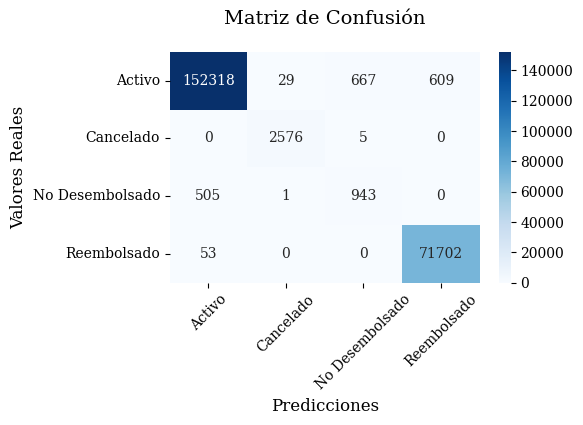

In [ ]:
y_pred2 = pipeline3.predict(X_test)

#Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred2))

#Matriz de Confusión
print("\nMatriz de Confusión (Counts):")
print(confusion_matrix(y_test, y_pred2))

#Visualización
plt.rcParams['font.family'] = 'serif'
plt.figure(figsize=(5, 3))
cm = confusion_matrix(y_test, y_pred2)
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=pipeline.classes_,
            yticklabels=pipeline.classes_)

plt.title('Matriz de Confusión', pad=20, fontsize=14)
plt.xlabel('Predicciones', fontsize=12)
plt.ylabel('Valores Reales', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

In [ ]:
report2=classification_report(y_test, y_pred2, output_dict=True)

In [ ]:
report_df = pd.DataFrame(report2).transpose()
report_df_filtered = report_df.drop(index='accuracy')

styled_report = (report_df_filtered.style
                .format("{:.2f}", subset=['precision', 'recall', 'f1-score'])
                .format("{:.0f}", subset=['support'])
                .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
                .set_caption("Classification Report"))
styled_report

,precision,recall,f1-score,support
Activo,1.00,0.99,0.99,153623
Cancelado,0.99,1.00,0.99,2581
No Desembolsado,0.58,0.65,0.62,1449
Reembolsado,0.99,1.00,1.00,71755
macro avg,0.89,0.91,0.90,229408
weighted avg,0.99,0.99,0.99,229408


<ipython-input-41-d00385475d65>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


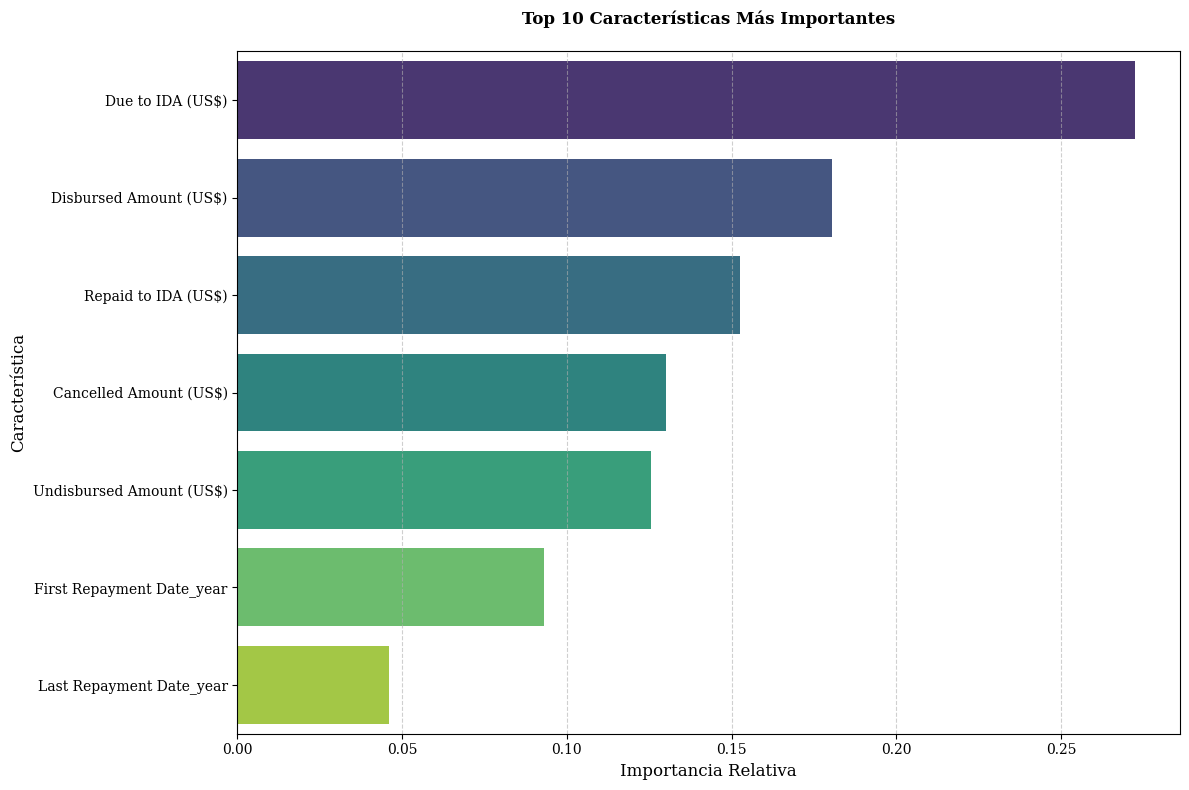

                  Feature  Importance
         Due to IDA (US$)    0.272502
   Disbursed Amount (US$)    0.180492
      Repaid to IDA (US$)    0.152429
   Cancelled Amount (US$)    0.130152
 Undisbursed Amount (US$)    0.125479
First Repayment Date_year    0.093057
 Last Repayment Date_year    0.045889


In [ ]:
# Obtener los nombres de las características después del preprocesamiento
numeric_feature_names = numeric_features

# Para variables categóricas
#categorical_encoder = pipeline3.named_steps['preprocessor'].named_transformers_['cat']
#categorical_feature_names = categorical_encoder.get_feature_names_out(categorical_features)

# Combinar todos los nombres
#all_feature_names = numeric_feature_names + list(categorical_feature_names)
all_feature_names = numeric_feature_names

importances = pipeline3.named_steps['classifier'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Visualizar las top 10 más importantes
plt.figure(figsize=(12, 8))
sns.barplot(
    data=feature_importance_df.head(10),
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title('Top 10 Características Más Importantes', fontweight='bold', pad=20)
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Característica', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 5. Mostrar tabla
print(feature_importance_df.head(20).to_string(index=False))

#Modelo 3

In [ ]:
# Definir features
numeric_features = ['Cancelled Amount (US$)', 'Undisbursed Amount (US$)','Disbursed Amount (US$)', 'Repaid to IDA (US$)',
                    'Due to IDA (US$)','First Repayment Date_year']


# Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
    ])

# Pipeline
pipeline4 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced'))
])

# Train-test split
X = df[numeric_features]
y = df['credit_status_group']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=46)

# Entrenamiento
pipeline4.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Cancelled Amount (US$)',
                                                   'Undisbursed Amount (US$)',
                                                   'Disbursed Amount (US$)',
                                                   'Repaid to IDA (US$)',
                                                   'Due to IDA (US$)',
                                                   'First Repayment '
                                                   'Date_year'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced'))])

Classification Report:
                 precision    recall  f1-score   support

         Activo       1.00      0.99      0.99    153623
      Cancelado       0.99      1.00      0.99      2581
No Desembolsado       0.50      0.57      0.53      1449
    Reembolsado       0.99      1.00      1.00     71755

       accuracy                           0.99    229408
      macro avg       0.87      0.89      0.88    229408
   weighted avg       0.99      0.99      0.99    229408


Matriz de Confusión (Counts):
[[152173     29    806    615]
 [     0   2576      5      0]
 [   624      1    824      0]
 [    53      0      0  71702]]


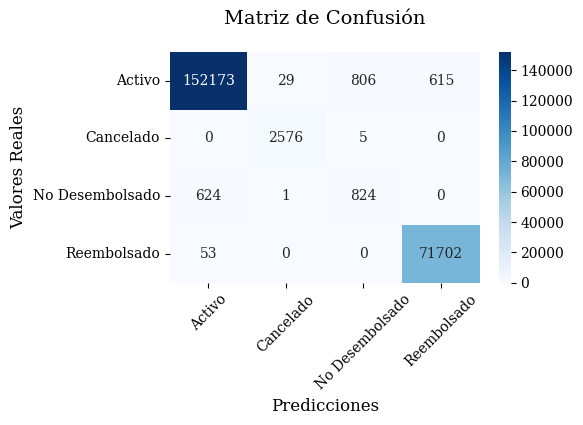

In [ ]:
y_pred3 = pipeline4.predict(X_test)

#Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred3))

#Matriz de Confusión
print("\nMatriz de Confusión (Counts):")
print(confusion_matrix(y_test, y_pred3))

#Visualización
plt.rcParams['font.family'] = 'serif'
plt.figure(figsize=(5, 3))
cm = confusion_matrix(y_test, y_pred3)
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=pipeline.classes_,
            yticklabels=pipeline.classes_)

plt.title('Matriz de Confusión', pad=20, fontsize=14)
plt.xlabel('Predicciones', fontsize=12)
plt.ylabel('Valores Reales', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

In [ ]:
report3=classification_report(y_test, y_pred3, output_dict=True)

In [ ]:
report_df = pd.DataFrame(report3).transpose()

# Aplicar estilos
styled_report = (report_df.style
                .format("{:.2f}", subset=['precision', 'recall', 'f1-score'])
                .format("{:.0f}", subset=['support'])
                .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
                .set_caption("Classification Report"))

styled_report

,precision,recall,f1-score,support
Activo,1.00,0.99,0.99,153623
Cancelado,0.99,1.00,0.99,2581
No Desembolsado,0.50,0.57,0.53,1449
Reembolsado,0.99,1.00,1.00,71755
accuracy,0.99,0.99,0.99,1
macro avg,0.87,0.89,0.88,229408
weighted avg,0.99,0.99,0.99,229408


In [ ]:
report_df = pd.DataFrame(report3).transpose()

# Eliminar la fila 'accuracy' antes de aplicar estilos
report_df_filtered = report_df.drop(index='accuracy')

styled_report = (report_df_filtered.style
                .format("{:.2f}", subset=['precision', 'recall', 'f1-score'])
                .format("{:.0f}", subset=['support'])
                .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
                .set_caption("Classification Report"))
styled_report

,precision,recall,f1-score,support
Activo,1.00,0.99,0.99,153623
Cancelado,0.99,1.00,0.99,2581
No Desembolsado,0.50,0.57,0.53,1449
Reembolsado,0.99,1.00,1.00,71755
macro avg,0.87,0.89,0.88,229408
weighted avg,0.99,0.99,0.99,229408
